In [1]:
import pandas as pd

df = pd.read_csv("../data/salary_data.csv")

df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [3]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [4]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [5]:
import matplotlib.pyplot as plt

## Skewsness

In [6]:
df.skew(numeric_only=True)

experience_years   -0.000952
skills_count        0.000302
certifications      0.004000
salary              0.379401
dtype: float64

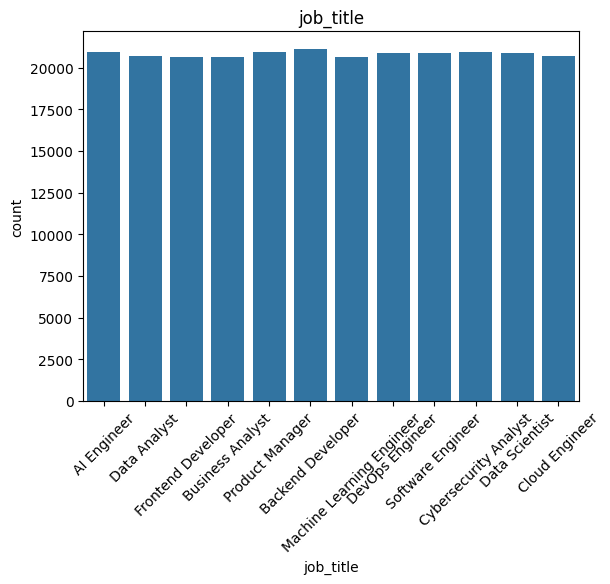

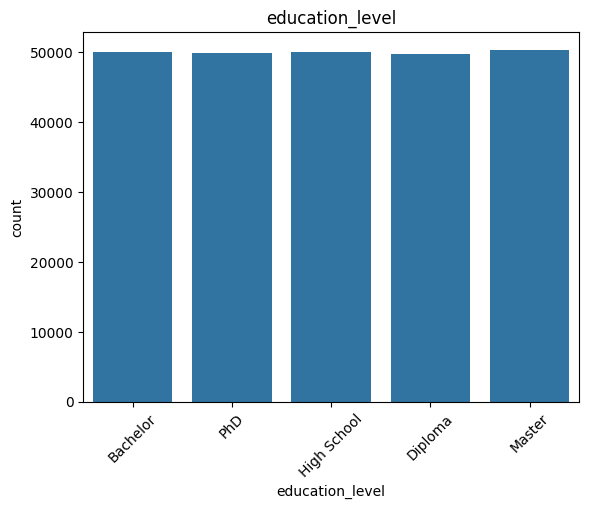

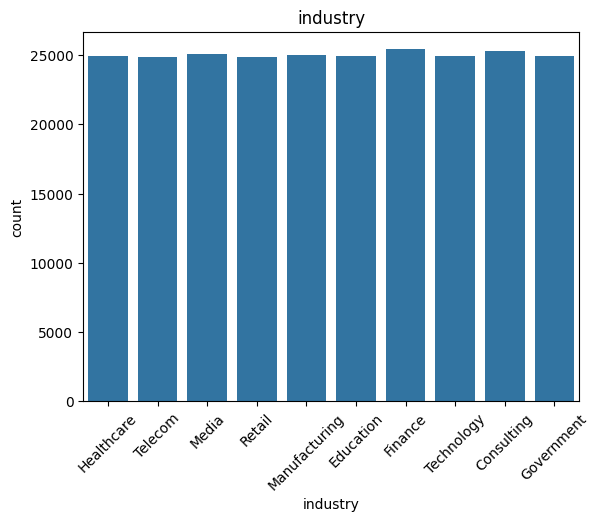

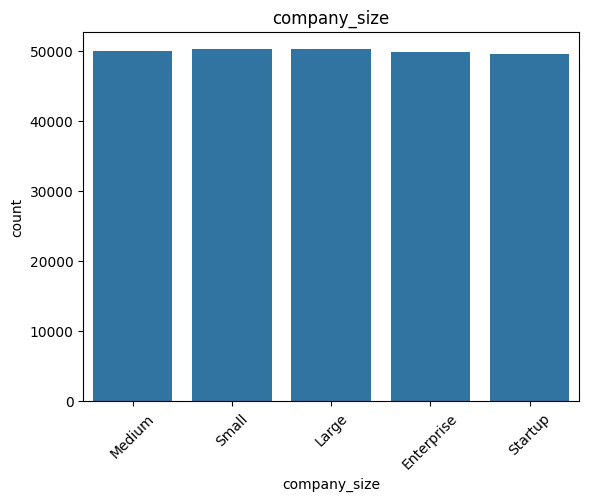

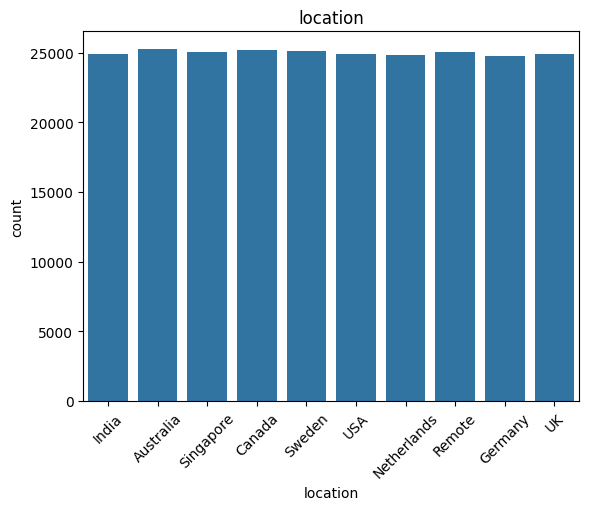

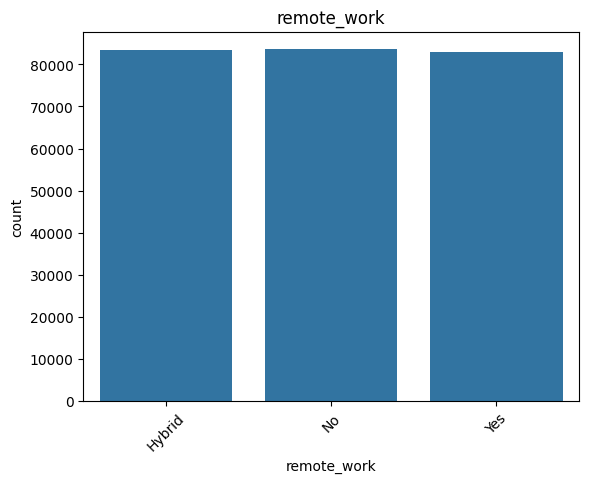

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['job_title','education_level','industry','company_size','location','remote_work']:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

<Axes: xlabel='experience_years', ylabel='salary'>

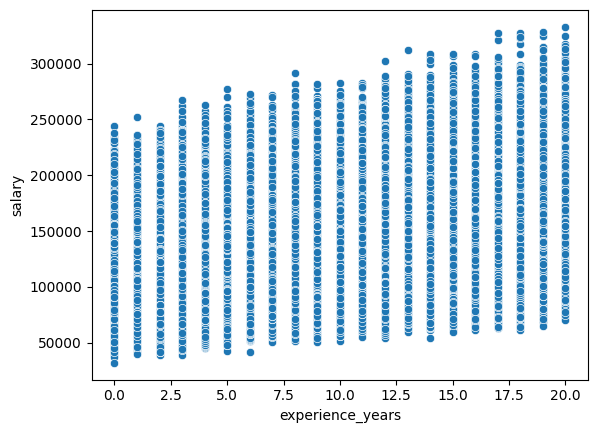

In [8]:
sns.scatterplot(x='experience_years', y='salary', data=df)

<Axes: xlabel='skills_count', ylabel='salary'>

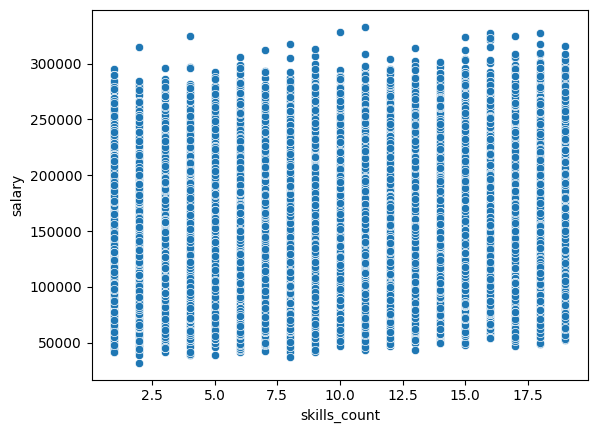

In [9]:
sns.scatterplot(x='skills_count', y='salary', data=df)

<Axes: xlabel='certifications', ylabel='salary'>

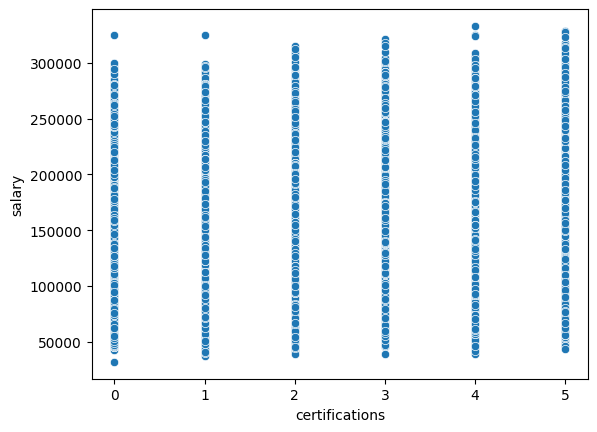

In [10]:
sns.scatterplot(x='certifications', y='salary', data=df)

<Axes: xlabel='education_level', ylabel='salary'>

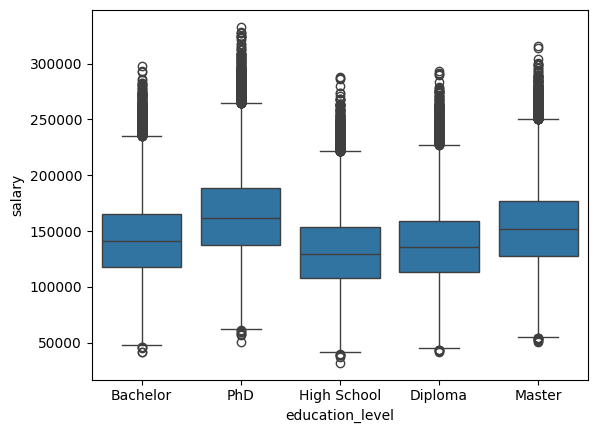

In [11]:
sns.boxplot(x='education_level', y='salary', data=df)

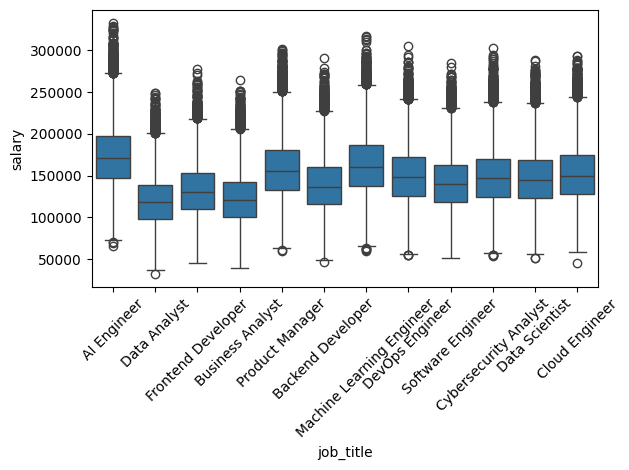

In [12]:
sns.boxplot(x='job_title', y='salary', data=df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: >

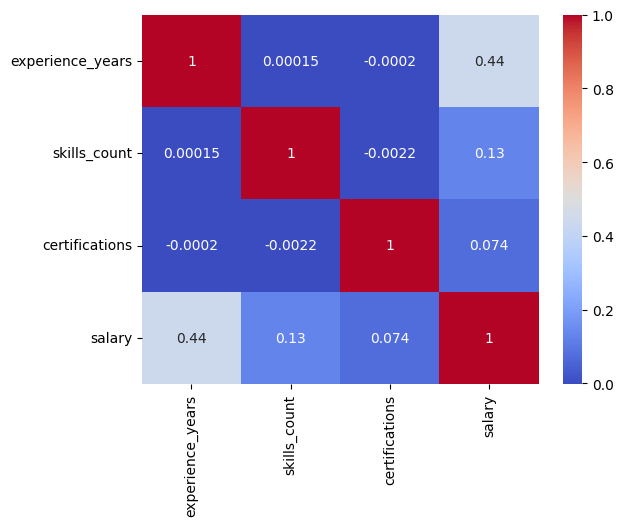

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [14]:
df.groupby('job_title')['salary'].mean().sort_values(ascending=False)

job_title
AI Engineer                  173498.480640
Machine Learning Engineer    163022.504570
Product Manager              157594.932029
Cloud Engineer               152102.535290
DevOps Engineer              149959.266791
Cybersecurity Analyst        148697.695548
Data Scientist               147258.214409
Software Engineer            141739.521460
Backend Developer            139202.768663
Frontend Developer           132653.842485
Business Analyst             122551.231354
Data Analyst                 119891.696603
Name: salary, dtype: float64

In [15]:
df.groupby('location')['salary'].mean().sort_values(ascending=False)

location
USA            181716.303919
Canada         167391.273396
UK             160075.143018
Germany        153376.211000
Remote         139442.525155
Sweden         139440.637291
Australia      139362.150804
Singapore      139340.696625
Netherlands    139294.813644
India           97690.402249
Name: salary, dtype: float64

In [16]:
df.groupby('remote_work')['salary'].mean().sort_values(ascending=False)

remote_work
Yes       149279.589822
Hybrid    143969.899839
No        143932.300941
Name: salary, dtype: float64

<Axes: ylabel='salary'>

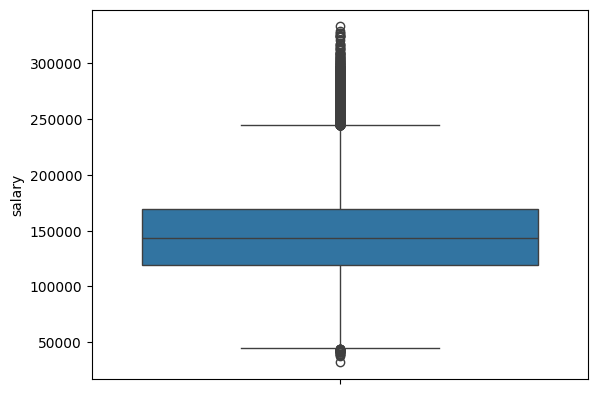

In [17]:
sns.boxplot(df['salary'])

In [18]:
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['salary'] < Q1 - 1.5*IQR) | (df['salary'] > Q3 + 1.5*IQR)]

In [19]:
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 2336
